In [1]:
import numpy as np
import matplotlib.pyplot as plt

# LV1 Rechnen mit Zweitoren

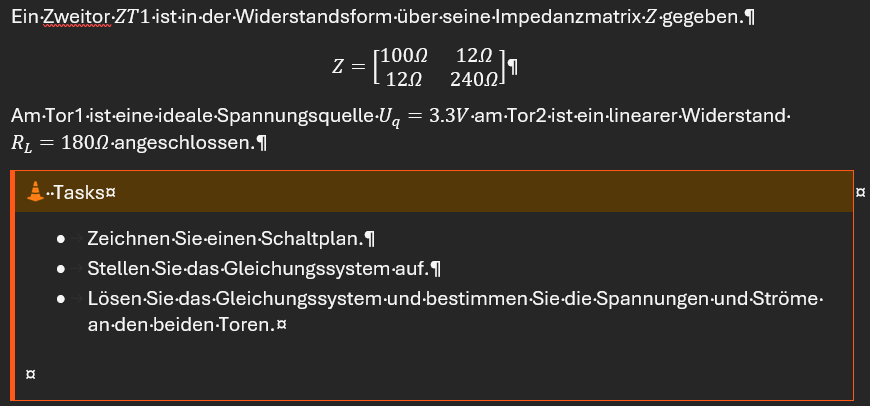

In [2]:
import numpy as np

# --- 1. Gegebene Werte und Matrix definieren ---
U_q = 3.3  # V
R_L = 180  # Ohm

# Z-Parameter Matrix (Z11, Z12, Z21, Z22)
Z = np.array([
    [100, 12],
    [12, 240]
])

# Koeffizientenmatrix A des Gleichungssystems:
# Erste Zeile: Z11 * I1 + Z12 * I2 = U_q
# Zweite Zeile: Z21 * I1 + (Z22 + R_L) * I2 = 0
A = np.array([
    [Z[0, 0], Z[0, 1]],
    [Z[1, 0], Z[1, 1] + R_L]
])

# Spannungsvektor U (rechte Seite der Gleichung)
U = np.array([U_q, 0])

# --- 2. Gleichungssystem lösen (A * I = U) ---
# Der solve-Befehl gibt den Vektor I = [I1, I2] zurück
I = np.linalg.solve(A, U)

# Ergebnisse in Variablen speichern
I1 = I[0]
I2 = I[1]

# --- 3. Spannungen U1 und U2 bestimmen ---

# U1 ist die Eingangsspannung, die gleich der idealen Quellspannung ist.
U1 = U_q

# U2 ist die Ausgangsspannung, die über R_L abfällt: U2 = -R_L * I2
U2 = -R_L * I2


# --- 4. Ergebnisse ausgeben ---

print("## Ergebnisse der Zweitor-Analyse")
print("-" * 30)

# Ströme
print(f"Strom I1 (Eingang): {I1 * 1000:.3f} mA")
print(f"Strom I2 (Ausgang): {I2 * 1000:.3f} mA")
print("-" * 30)

# Spannungen
print(f"Spannung U1 (Eingang): {U1:.3f} V")
print(f"Spannung U2 (Ausgang): {U2:.3f} V")

## Ergebnisse der Zweitor-Analyse
------------------------------
Strom I1 (Eingang): 33.114 mA
Strom I2 (Ausgang): -0.946 mA
------------------------------
Spannung U1 (Eingang): 3.300 V
Spannung U2 (Ausgang): 0.170 V


# LV2 Umrechnung in die Leitform Y

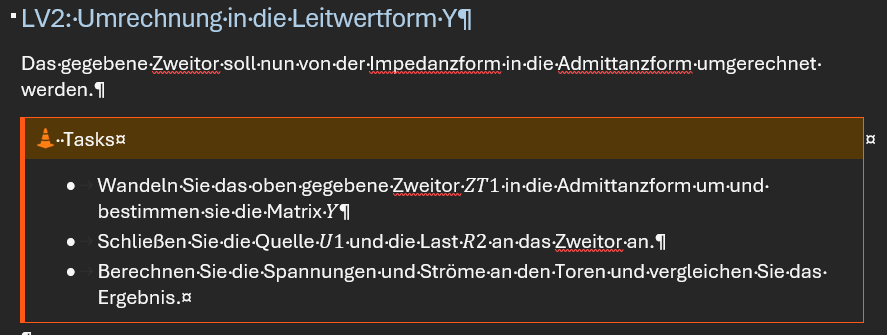

In [8]:
print(Z)
Z1 = Z[0,0] - Z[0,1] #Z1
Z3 = Z[1,1] - Z[0,1] #Z3
Z2 = Z[0,1] #Z2

print(f"Z_A: {Z1} Ohm")
print(f"Z_B: {Z3} Ohm")
print(f"Z_C: {Z2} Ohm")

Y11 = (Z2+Z3)/(Z1*Z2+Z1*Z3+Z2*Z3)
Y12 = -Z2/(Z1*Z2+Z1*Z3+Z2*Z3)
Y21 = -Z2/(Z1*Z2+Z1*Z3+Z2*Z3)
Y22 = (Z1+Z2)/(Z1*Z2+Z1*Z3+Z2*Z3)

print("Admittanzmatrix Y:")
print(f"Y11: {Y11} S")
print(f"Y12: {Y12} S")
print(f"Y21: {Y21} S")
print(f"Y22: {Y22} S")

Y = np.array([
    [Y11, Y12],
    [Y21, Y22]
])


U_q = 3.3  # V
R_L = 180  # Ohm

# Tor 1 Spannung (gegeben)
U1 = U_q

# Berechnung von I2 (siehe abgeleitete Formel)
I2_numerator = Y21 * U1
I2_denominator = 1 + Y22 * R_L
I2_result = I2_numerator / I2_denominator

# Berechnung von U2 (Lastbedingung)
U2_result = -R_L * I2_result

# Berechnung von I1 (Y-Matrix Gleichung 1)
I1_result = Y11 * U1 + Y12 * U2_result

# --- 5. Ergebnisse ausgeben ---

print("\n## Ergebnisse (gelöst über Y-Matrix)")
print("-" * 35)
print(f"Spannung U1 (Eingang): {U1:.3f} V")
print(f"Strom I1 (Eingang): {I1_result * 1000:.3f} mA")
print("-" * 35)
print(f"Strom I2 (Ausgang): {I2_result * 1000:.3f} mA")
print(f"Spannung U2 (Ausgang): {U2_result:.3f} V")

[[100  12]
 [ 12 240]]
Z_A: 88 Ohm
Z_B: 228 Ohm
Z_C: 12 Ohm
Admittanzmatrix Y:
Y11: 0.01006036217303823 S
Y12: -0.0005030181086519115 S
Y21: -0.0005030181086519115 S
Y22: 0.0041918175720992625 S

## Ergebnisse (gelöst über Y-Matrix)
-----------------------------------
Spannung U1 (Eingang): 3.300 V
Strom I1 (Eingang): 33.114 mA
-----------------------------------
Strom I2 (Ausgang): -0.946 mA
Spannung U2 (Ausgang): 0.170 V


# LV3 Reihen-Reihen Schaltung

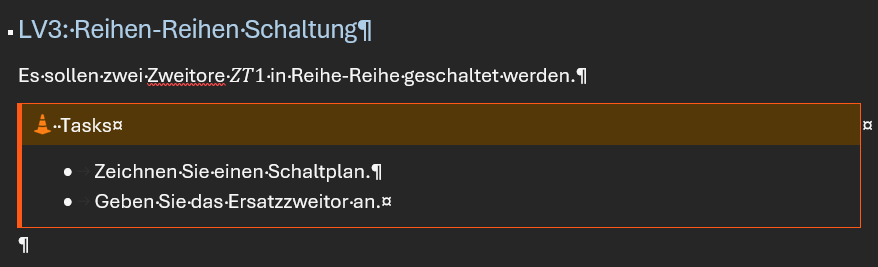

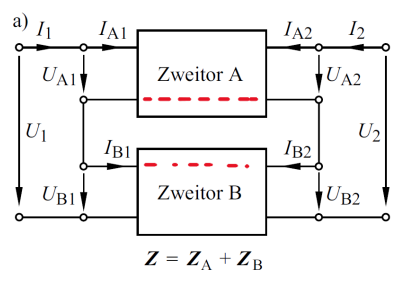

In [9]:
ZReihenReihen = Z + Z
print("Z-Reihen:")
print(ZReihenReihen)

Z-Reihen:
[[200  24]
 [ 24 480]]


# LV4 Parallel-Parallel Schaltung

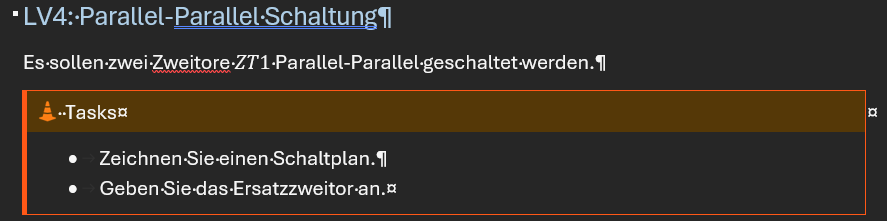

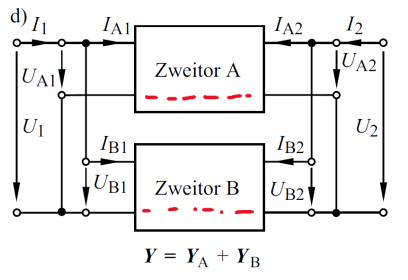

In [10]:
ZParallelParallel = Y + Y
print("Z-Parallel:")
print(ZParallelParallel)

Z-Parallel:
[[ 0.02012072 -0.00100604]
 [-0.00100604  0.00838364]]


# Laborübung